In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("Filemaker_CLEAN.csv")
df.head()

,experience_id,major_department,major_unit,notes,person_id,record_id,experience_name,experience_term,experience_type,experience_year,...,participant_experience_type_unique,participant_experience_year_unique,participant_major_unit_unique,participant_record_id_unique,uniqname,registrar_type,class_year,term_season,year,student_name
0,182.0,Dance,"Music, Theatre & Dance",Credit Hours: 1,415.0,689.0,ARTSADMN 423-1,FA 2019,Course,2019-2020,...,Course,2019-2020,"Music, Theatre & Dance",689.0,abniemi,Major,Sophomore,FA,2019,Abby Niemi
1,182.0,Dance,"Music, Theatre & Dance",Credit Hours: 1,415.0,689.0,ARTSADMN 423-1,FA 2019,Course,2019-2020,...,Counseling Appointment,2020-2021,"Music, Theatre & Dance Music, Theatre & Dance",14905.0,abniemi,Major,Sophomore,FA,2019,Abby Niemi
2,178.0,Theatre & Drama,"Music, Theatre & Dance",Credit Hours: 1,416.0,690.0,ARTSADMN 406-2,FA 2019,Course,2019-2020,...,Course,2019-2020,"Music, Theatre & Dance",690.0,acurnow,Major,Sophomore,FA,2019,Alix Curnow
3,178.0,Theatre & Drama,"Music, Theatre & Dance",Credit Hours: 1,416.0,690.0,ARTSADMN 406-2,FA 2019,Course,2019-2020,...,Event,2019-2020,"Music, Theatre & Dance",2666.0,acurnow,Major,Sophomore,FA,2019,Alix Curnow
4,178.0,Theatre & Drama,"Music, Theatre & Dance",Credit Hours: 1,416.0,690.0,ARTSADMN 406-2,FA 2019,Course,2019-2020,...,Event,2017-2018,"Music, Theatre & Dance",9947.0,acurnow,Major,Sophomore,FA,2019,Alix Curnow


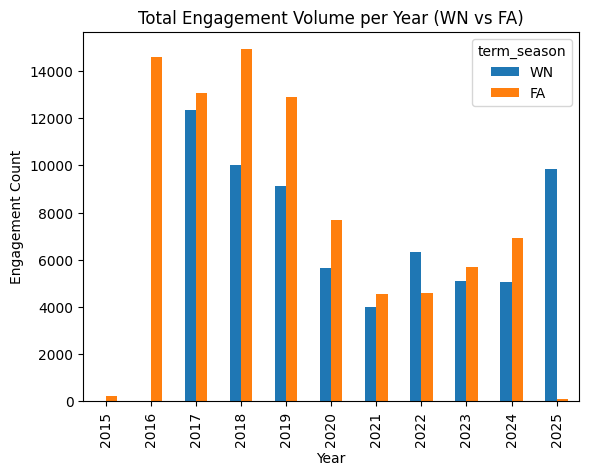

In [13]:
# -- Total Engagement Volume Per Year --

engagements = (
    df.groupby(["year", "term_season"])["experience_id"]
    .count()
    .reset_index(name="count")
)

pivot = engagements.pivot(index="year", columns="term_season", values="count").fillna(0)
pivot = pivot.reindex(columns=["WN", "FA"], fill_value=0)

pivot.plot(kind='bar')
plt.title("Total Engagement Volume per Year (WN vs FA)")
plt.xlabel("Year")
plt.ylabel("Engagement Count")
plt.show()

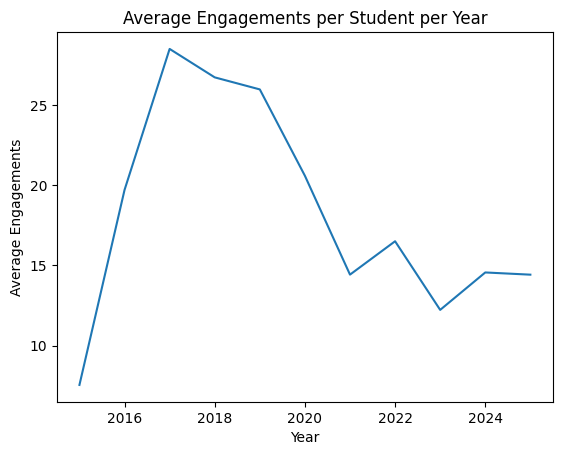

In [14]:
# -- Average Engagements per Student per Year --

per_student_year = (
    df.groupby(["year", "uniqname"])["experience_id"]
    .count()
    .reset_index(name="engagements")
)

avg_per_year = per_student_year.groupby("year")["engagements"].mean()

plt.figure()
avg_per_year.plot()
plt.title("Average Engagements per Student per Year")
plt.xlabel("Year")
plt.ylabel("Average Engagements")
plt.show()

<Figure size 640x480 with 0 Axes>

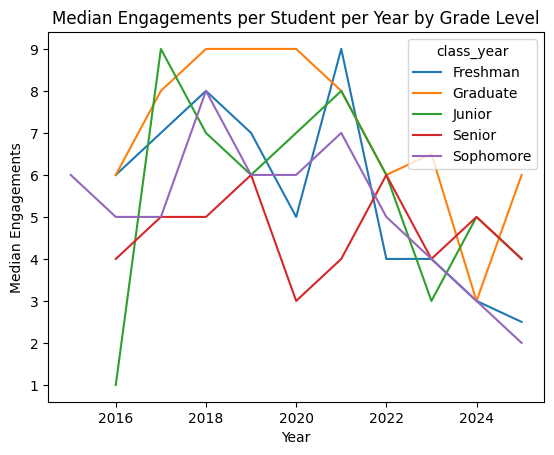

In [15]:
# -- Avg Engagements per Student per Year by Grade Level -- 
per_student_year_class = (
    df.groupby(["year", "uniqname", "class_year"])["experience_id"]
    .count()
    .reset_index(name="engagements")
)

avg_by_class = (
    per_student_year_class
    .groupby(["year", "class_year"])["engagements"]
    .median()
    .unstack()
)

plt.figure()
avg_by_class.plot()
plt.title("Median Engagements per Student per Year by Grade Level")
plt.xlabel("Year")
plt.ylabel("Median Engagements")
plt.show()

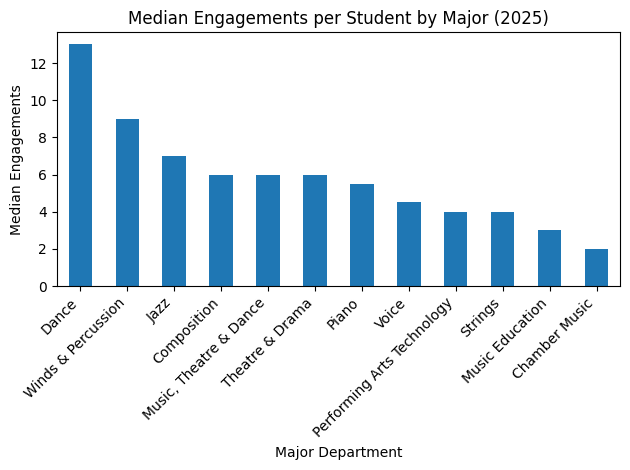

In [16]:
# Step 1: filter majors with > 1000 occurrences (across full dataset)
valid_majors = (
    df["major_department"]
    .value_counts()
    .loc[lambda x: x > 3000]
    .index
)

# Step 2: filter for 2025 + valid majors
df_2025 = df[
    (df["year"] == 2025) &
    (df["major_department"].isin(valid_majors))
]

# Step 3: engagements per student per major
per_student_major = (
    df_2025.groupby(["uniqname", "major_department"])["experience_id"]
    .count()
    .reset_index(name="engagements")
)

# Step 4: average engagements per major
avg_by_major_2025 = (
    per_student_major
    .groupby("major_department")["engagements"]
    .median()
    .sort_values(ascending=False)
)

# Step 5: bar chart
plt.figure()
avg_by_major_2025.plot(kind="bar")
plt.title("Median Engagements per Student by Major (2025)")
plt.xlabel("Major Department")
plt.ylabel("Median Engagements")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

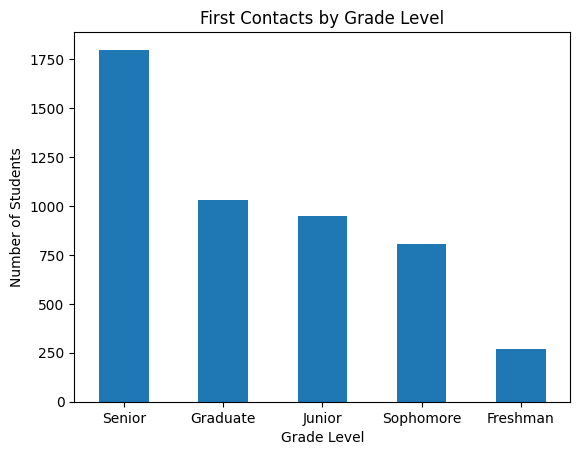

In [17]:
# First engagement per student
first_contact = (
    df.groupby("person_id")[["year", "experience_term", "class_year"]]
    .first()
    .reset_index()
)

first_counts = first_contact["class_year"].value_counts()

plt.figure()
first_counts.plot(kind="bar")
plt.title("First Contacts by Grade Level")
plt.xlabel("Grade Level")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)
plt.show()

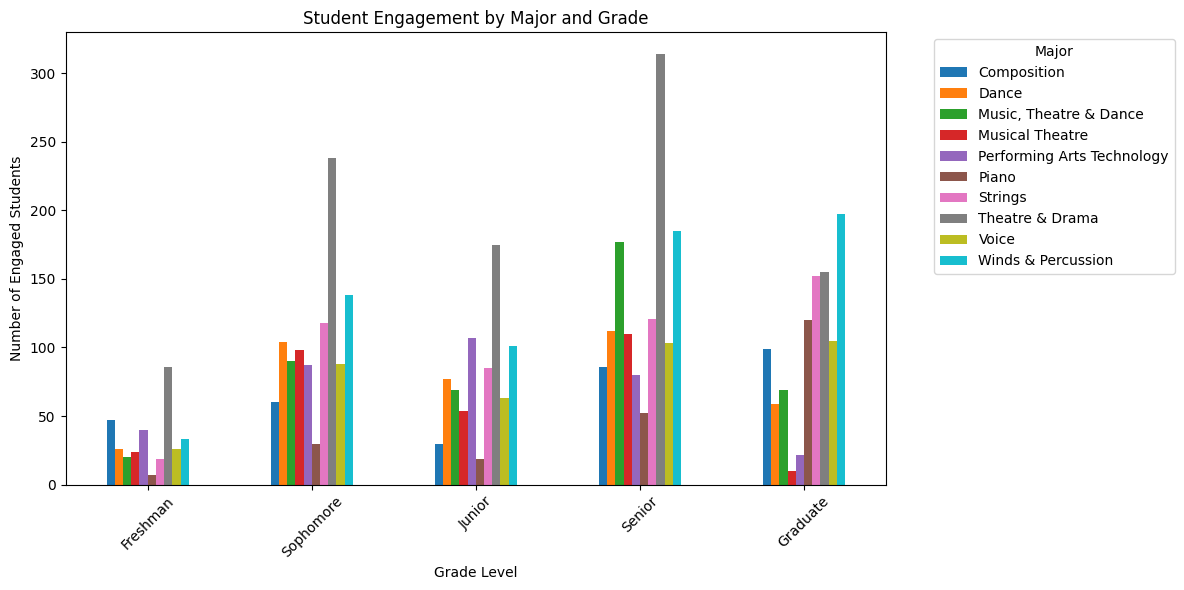

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Clean major names FIRST
df = df.copy()

df["major_department"] = (
    df["major_department"]
    .astype(str)
    .str.strip()
)

# 2. Build engagement table
engagement_by_major_grade = (
    df.groupby(["major_department", "class_year"])["student_name"]
    .nunique()
    .reset_index()
)

engagement_by_major_grade.columns = [
    "major_department",
    "grade",
    "num_engaged_students"
]

engagement_by_major_grade["grade"] = (
    engagement_by_major_grade["grade"]
    .astype(str)
    .str.strip()
)

# 3. Collapse graduate categories
graduate_labels = {
    "G Pre-Cand",
    "Grad Cand",
    "Grad Cert",
    "Grad Inter",
    "Grad Mastr",
    "Masters",
    "Doctorate",
    "Pro 2nd YR"
}

engagement_by_major_grade.loc[
    engagement_by_major_grade["grade"].isin(graduate_labels),
    "grade"
] = "Graduate"

# Remove true junk labels
engagement_by_major_grade = engagement_by_major_grade[
    ~engagement_by_major_grade["grade"].isin(["School Year", "USpec/NCFD"])
]

# 4. Compute top majors (after cleaning)
top_majors = (
    engagement_by_major_grade
    .groupby("major_department")["num_engaged_students"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

top_engagement = engagement_by_major_grade[
    engagement_by_major_grade["major_department"].isin(top_majors)
]

# 5. Aggregate again for plotting
top_engagement = (
    top_engagement
    .groupby(["major_department", "grade"])["num_engaged_students"]
    .sum()
    .reset_index()
)

# 6. Grade ordering
grade_order = ["Freshman", "Sophomore", "Junior", "Senior", "Graduate"]

top_engagement["grade"] = pd.Categorical(
    top_engagement["grade"],
    categories=grade_order,
    ordered=True
)

top_engagement = top_engagement.sort_values("grade")

# 7. Pivot + plot
pivot = top_engagement.pivot_table(
    index="grade",
    columns="major_department",
    values="num_engaged_students",
    aggfunc="sum",
    fill_value=0
)

fig, ax = plt.subplots(figsize=(12, 6))
pivot.plot(kind="bar", ax=ax)

plt.title("Student Engagement by Major and Grade")
plt.xlabel("Grade Level")
plt.ylabel("Number of Engaged Students")
plt.legend(title="Major", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

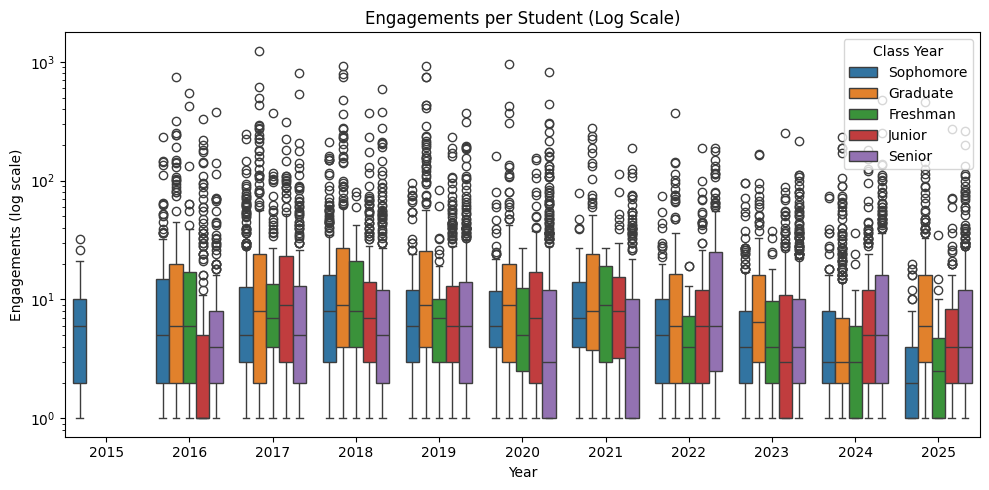

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

per_student_year_class = (
    df.groupby(["year", "uniqname", "class_year"])["experience_id"]
    .count()
    .reset_index(name="engagements")
)

plt.figure(figsize=(10,5))

sns.boxplot(
    data=per_student_year_class,
    x="year",
    y="engagements",
    hue="class_year"
)

plt.yscale("log")

plt.title("Engagements per Student (Log Scale)")
plt.xlabel("Year")
plt.ylabel("Engagements (log scale)")
plt.legend(title="Class Year")
plt.tight_layout()
plt.show()

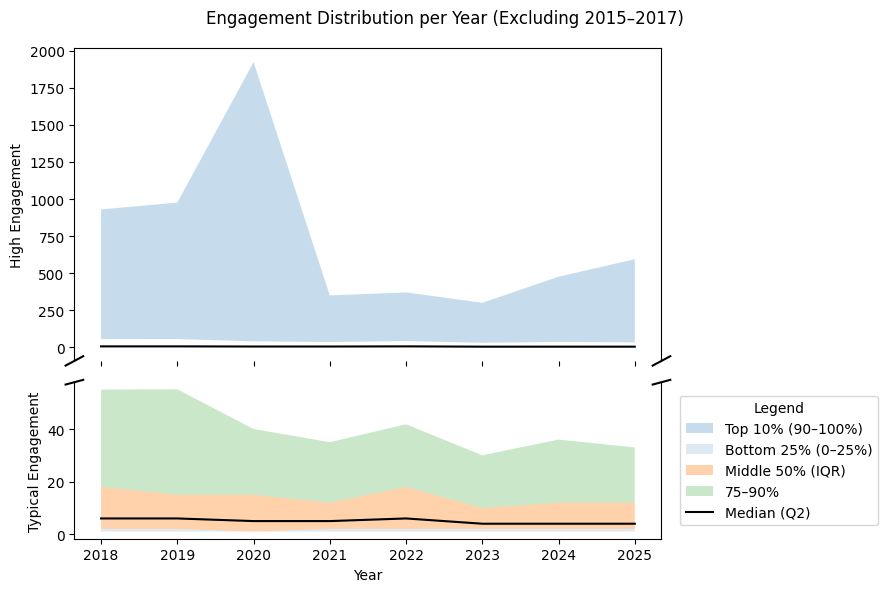

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

df_filtered = df[~df["year"].isin([2015, 2016, 2017])]

per_student_year = (
    df_filtered.groupby(["year", "uniqname"])["experience_id"]
    .count()
    .reset_index(name="engagements")
)

stats = (
    per_student_year
    .groupby("year")["engagements"]
    .quantile([0.0, 0.25, 0.5, 0.75, 0.9, 1.0])
    .unstack()
    .reset_index()
)

stats.columns = ["year", "min", "p25", "median", "p75", "p90", "max"]

fig, (ax1, ax2) = plt.subplots(
    2, 1, sharex=True, figsize=(9,6),
    gridspec_kw={"height_ratios": [2, 1]}
)

# --- TOP: extreme tail (90–100%) ---
ax1.fill_between(
    stats["year"], stats["p90"], stats["max"],
    alpha=0.25,
    label="Top 10% (90–100%)"
)
ax1.plot(stats["year"], stats["median"], color="black")

ax1.set_ylabel("High Engagement")

# --- BOTTOM: full distribution ---
ax2.fill_between(stats["year"], stats["min"], stats["p25"],
                 alpha=0.15, label="Bottom 25% (0–25%)")

ax2.fill_between(stats["year"], stats["p25"], stats["p75"],
                 alpha=0.35, label="Middle 50% (IQR)")

ax2.fill_between(stats["year"], stats["p75"], stats["p90"],
                 alpha=0.25, label="75–90%")

ax2.plot(stats["year"], stats["median"],
         color="black", label="Median (Q2)")

ax2.set_ylabel("Typical Engagement")
ax2.set_xlabel("Year")

# --- SINGLE LEGEND FOR EVERYTHING ---
handles, labels = ax2.get_legend_handles_labels()
handles2, labels2 = ax1.get_legend_handles_labels()

ax2.legend(
    handles2 + handles,
    labels2 + labels,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    title="Legend"
)

# axis break styling
ax1.spines["bottom"].set_visible(False)
ax2.spines["top"].set_visible(False)

d = 0.015
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((-d, +d), (-d, +d), **kwargs)
ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)

kwargs.update(transform=ax2.transAxes)
ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)
ax2.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

plt.suptitle("Engagement Distribution per Year (Excluding 2015–2017)")
plt.tight_layout()
plt.show()